# 03 — Modeling

**Pipeline stage:** `Health Indicator -> RUL Prediction`

Five different model families compete on the same task here, each representing a different
angle on the RUL problem:

| Model | Family | Idea |
|---|---|---|
| XGBoost | gradient-boosted trees | strong tabular baseline on engineered rolling-window features |
| LSTM | recurrent neural net | reads the raw sensor sequence, carries state cycle-to-cycle |
| TCN | dilated causal convolutions | exponentially growing receptive field, no recurrence |
| Transformer | self-attention | attends directly to any past cycle in the window |
| Weibull AFT | survival analysis | models RUL as a full time-to-failure *distribution*, not a point estimate |

The neural sequence models (LSTM/TCN/Transformer) were trained offline via
`scripts/train_sequence.py --subset all --model all` — training all three on all four
subsets on CPU takes a while, so this notebook loads the resulting checkpoints rather than
retraining them live. XGBoost trains in seconds, so we do that one live, right here.


In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from aerorul.evaluation.metrics import evaluate
from aerorul.features.pipeline import build_training_data, last_cycle_per_unit
from aerorul.models.baseline_xgboost import predict as predict_xgb
from aerorul.models.baseline_xgboost import train_xgboost
from aerorul.models.lstm import load_lstm, predict_lstm
from aerorul.models.sequence_common import build_last_sequence_per_unit
from aerorul.models.survival import build_censored_frame, predict_median_rul
from aerorul.models.tcn import load_tcn, predict_tcn
from aerorul.models.transformer import load_transformer, predict_transformer

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

MODELS_DIR = Path("../models_store") if Path("../models_store").exists() else Path("models_store")
SEQUENCE_LOADERS = {
    "lstm": (load_lstm, predict_lstm),
    "tcn": (load_tcn, predict_tcn),
    "transformer": (load_transformer, predict_transformer),
}


## 1. Baseline: XGBoost on engineered features

Gradient-boosted trees over the full engineered feature set (raw sensors/settings + rolling
mean/std at 5/10/20-cycle windows). No temporal architecture needed — the rolling features
already encode "how has this been trending," so a tree ensemble just has to learn the
(nonlinear, but not sequential) mapping from that snapshot to RUL.


In [2]:
train_df, test_df, pipeline, data = build_training_data("FD001")
test_last = last_cycle_per_unit(test_df)

X_train, y_train = train_df[pipeline.all_feature_cols], train_df["RUL"]
X_test = test_last[pipeline.all_feature_cols]
y_test = test_last["unit_number"].map(data.rul_truth).to_numpy()  # true RUL, not the capped label

xgb_model = train_xgboost(X_train, y_train)
xgb_pred = predict_xgb(xgb_model, X_test)

xgb_metrics = evaluate(y_test, xgb_pred)
print(f"FD001 XGBoost — RMSE={xgb_metrics['rmse']:.2f}  MAE={xgb_metrics['mae']:.2f}  "
      f"NASA score={xgb_metrics['nasa_score']:.1f}")


FD001 XGBoost — RMSE=18.98  MAE=13.82  NASA score=1138.2


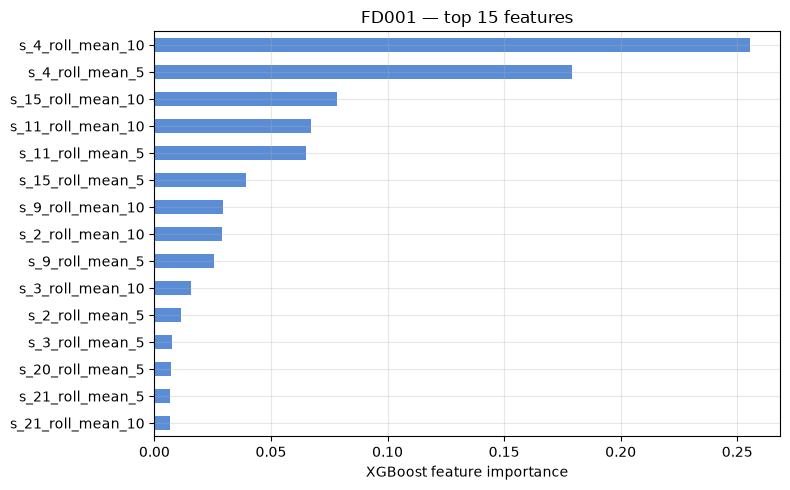

In [3]:
importances = pd.Series(xgb_model.feature_importances_, index=pipeline.all_feature_cols)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
top15[::-1].plot.barh(ax=ax, color="#5b8dd6")
ax.set_xlabel("XGBoost feature importance")
ax.set_title("FD001 — top 15 features")
plt.tight_layout()
plt.show()


Rolling-window features dominate the top of the importance ranking — confirming that the
manual feature engineering in notebook 01 (not just the raw sensor snapshot) is doing real
work for the tree-based model.


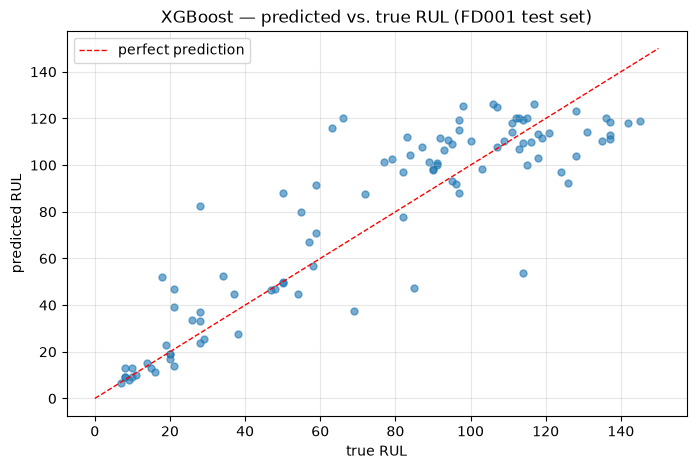

In [4]:
fig, ax = plt.subplots()
ax.scatter(y_test, xgb_pred, alpha=0.6, s=25)
lims = [0, max(y_test.max(), xgb_pred.max()) + 5]
ax.plot(lims, lims, "r--", lw=1, label="perfect prediction")
ax.set_xlabel("true RUL")
ax.set_ylabel("predicted RUL")
ax.set_title("XGBoost — predicted vs. true RUL (FD001 test set)")
ax.legend()
plt.show()


## 2. Sequence models: LSTM, TCN, Transformer

All three read a 30-cycle window of *raw, normalized* sensor values (not the rolling-stat
features XGBoost uses) — the whole point of a sequence model is to let it learn its own
temporal features instead of hand-crafting them:

- **LSTM** — a 2-layer recurrent network; carries a hidden state cycle-to-cycle, naturally
  suited to sequential data but must process the window strictly in order.
- **TCN** — stacked dilated causal convolutions (dilation 1, 2, 4 across 3 blocks); an
  exponentially growing receptive field without any recurrence, so it's fully parallelizable
  during training.
- **Transformer** — a small self-attention encoder (2 layers, 4 heads); attends directly to
  any cycle in the window rather than propagating information step by step.

Let's load the FD001 checkpoints and compare parameter counts alongside the architectural
description above.


In [5]:
fd001_meta = {m: joblib.load(MODELS_DIR / f"FD001_{m}_meta.joblib") for m in SEQUENCE_LOADERS}
n_features = fd001_meta["lstm"]["n_features"]

param_counts = {}
seq_models = {}
for model_type, (loader, _) in SEQUENCE_LOADERS.items():
    model, _ = loader(str(MODELS_DIR / f"FD001_{model_type}.pt"), n_features)
    seq_models[model_type] = model
    param_counts[model_type] = sum(p.numel() for p in model.parameters())

pd.Series(param_counts, name="trainable parameters").to_frame()


,trainable parameters
lstm,56641
tcn,34593
transformer,70209


In [6]:
X_test_seq, _, units_test = build_last_sequence_per_unit(
    test_df, fd001_meta["transformer"]["feature_cols"], fd001_meta["transformer"]["seq_len"]
)
y_test_seq = pd.Series(units_test).map(data.rul_truth).to_numpy()

seq_preds = {}
for model_type, (_, predictor) in SEQUENCE_LOADERS.items():
    meta = fd001_meta[model_type]
    preds = predictor(seq_models[model_type], X_test_seq, meta["rul_cap"])
    seq_preds[model_type] = preds
    m = evaluate(y_test_seq, preds)
    print(f"FD001 {model_type:<12} RMSE={m['rmse']:6.2f}  MAE={m['mae']:6.2f}  NASA={m['nasa_score']:8.1f}")


FD001 lstm         RMSE= 17.71  MAE= 13.50  NASA=   747.3
FD001 tcn          RMSE= 17.50  MAE= 12.40  NASA=   557.8
FD001 transformer  RMSE= 16.04  MAE= 12.16  NASA=   438.6


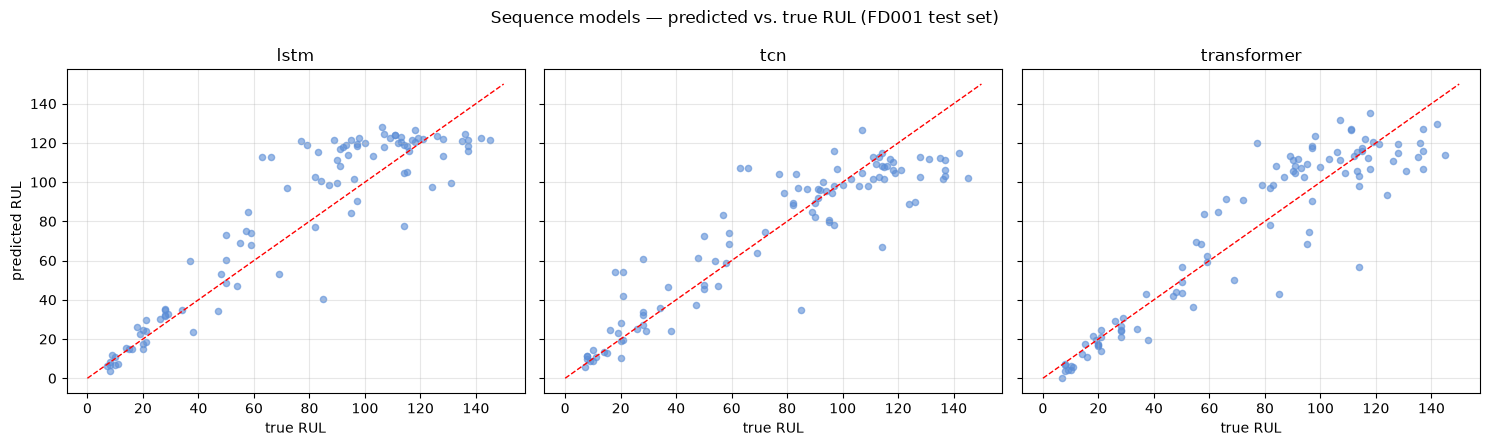

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, model_type in zip(axes, SEQUENCE_LOADERS):
    ax.scatter(y_test_seq, seq_preds[model_type], alpha=0.6, s=20, color="#5b8dd6")
    lims = [0, max(y_test_seq.max(), seq_preds[model_type].max()) + 5]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_title(model_type)
    ax.set_xlabel("true RUL")
axes[0].set_ylabel("predicted RUL")
plt.suptitle("Sequence models — predicted vs. true RUL (FD001 test set)")
plt.tight_layout()
plt.show()


## 3. Survival analysis: Weibull AFT

Instead of a single point estimate, this model predicts a full survival distribution — the
probability an engine is *still running* at any future cycle, conditioned on its early-life
sensor signature. See notebook 04 for the calibration/uncertainty story in more depth; here
we just check its point-estimate accuracy (median of the predicted distribution) alongside
the other four models, and its concordance index (a ranking metric: does the model correctly
order which of two random engines fails first?).


In [8]:
survival_bundle = joblib.load(MODELS_DIR / "FD001_survival.joblib")
survival_model, feature_cols = survival_bundle["model"], survival_bundle["feature_cols"]

censored_frame = build_censored_frame(test_df, feature_cols)
survival_pred = predict_median_rul(survival_model, censored_frame[feature_cols]).to_numpy()
survival_true = censored_frame.index.to_series().map(data.rul_truth).to_numpy()

survival_metrics = evaluate(survival_true, survival_pred)
print(f"FD001 survival — RMSE={survival_metrics['rmse']:.2f}  MAE={survival_metrics['mae']:.2f}  "
      f"NASA={survival_metrics['nasa_score']:.1f}  train concordance={survival_model.concordance_index_:.3f}")


FD001 survival — RMSE=27.76  MAE=22.86  NASA=1527.1  train concordance=0.802


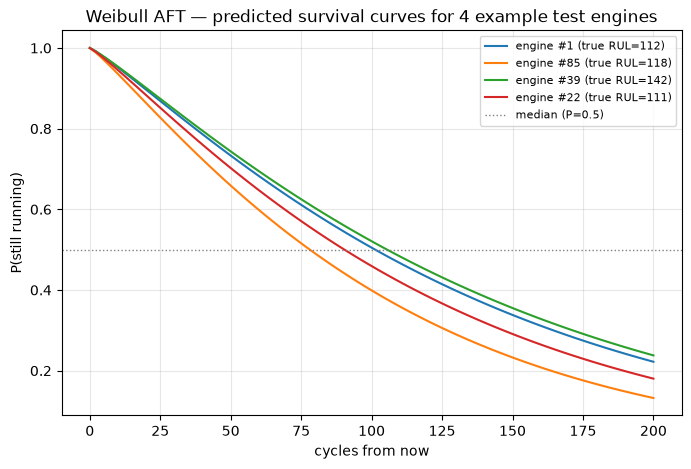

In [9]:
example_units = censored_frame.index[:4]
times = np.linspace(0, 200, 100)
survival_curves = survival_model.predict_survival_function(censored_frame.loc[example_units, feature_cols], times=times)

fig, ax = plt.subplots()
for unit in example_units:
    true_rul = data.rul_truth.loc[unit]
    ax.plot(times, survival_curves[unit], label=f"engine #{unit} (true RUL={true_rul})")
ax.axhline(0.5, color="gray", ls=":", lw=1, label="median (P=0.5)")
ax.set_xlabel("cycles from now")
ax.set_ylabel("P(still running)")
ax.set_title("Weibull AFT — predicted survival curves for 4 example test engines")
ax.legend(fontsize=8)
plt.show()


## 4. Full comparison across all 4 subsets

`scripts/compare_models.py` evaluates every trained model consistently (against the true,
uncapped RUL) and writes the winner per subset to `models_store/champion.json` — the file
the API reads at startup to decide which model to serve.


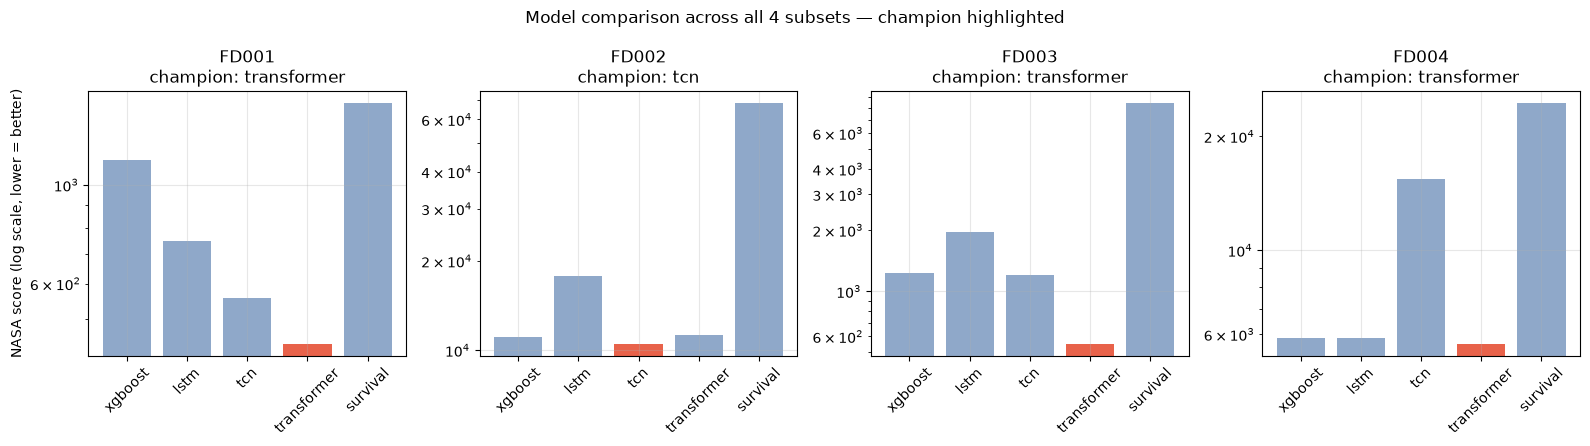

In [10]:
with open(MODELS_DIR / "champion.json") as f:
    champions = json.load(f)

model_order = ["xgboost", "lstm", "tcn", "transformer", "survival"]
subsets_order = list(champions.keys())

fig, axes = plt.subplots(1, len(subsets_order), figsize=(16, 4.5), sharey=False)
for ax, subset in zip(axes, subsets_order):
    metrics = champions[subset]["metrics"]
    champion = champions[subset]["champion"]
    scores = [metrics[m]["nasa_score"] for m in model_order]
    colors = ["#e8624a" if m == champion else "#8fa8c9" for m in model_order]
    ax.bar(model_order, scores, color=colors)
    ax.set_yscale("log")
    ax.set_title(f"{subset}\nchampion: {champion}")
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("NASA score (log scale, lower = better)")
plt.suptitle("Model comparison across all 4 subsets — champion highlighted")
plt.tight_layout()
plt.show()


In [11]:
rows = []
for subset, info in champions.items():
    m = info["metrics"][info["champion"]]
    rows.append({"subset": subset, "champion": info["champion"], **{k: round(v, 1) for k, v in m.items()}})
pd.DataFrame(rows).set_index("subset")


,champion,rmse,mae,nasa_score
subset,,,,
FD001,transformer,16.0,12.2,438.6
FD002,tcn,28.3,19.3,10486.4
FD003,transformer,16.0,11.7,549.3
FD004,transformer,26.6,19.5,5647.4


## 5. What actually decides the winner

XGBoost is competitive with the deep models on FD002 (the hardest subset by every measure in
notebook 02) but loses clearly on the single-condition subsets, where the sequence models'
ability to learn temporal patterns directly pays off. Survival analysis never wins on NASA
score despite solid ranking ability (~0.80+ concordance) — its median predictions are
occasionally badly wrong for a handful of engines, and the NASA scoring function's asymmetric
penalty (late predictions cost far more than early ones) punishes those outliers heavily.
That's a real, informative tradeoff, not a bug: it's the only model here producing a full
probability distribution over failure time rather than a single number, which is valuable
for some questions even when its point accuracy trails.


## Summary

- XGBoost is a strong, fast baseline but the neural sequence models generally beat it on the
  single-condition subsets (FD001/FD003), where there's a cleaner temporal pattern to learn.
- On the harder multi-condition subsets (FD002/FD004), the gap narrows dramatically — this
  project's "champion" isn't the same architecture everywhere, which is exactly why
  `compare_models.py` exists instead of hard-coding one model.
- Weibull AFT survival analysis trades point-estimate accuracy for a genuine probability
  distribution over time-to-failure — worth keeping even though it doesn't win on NASA score.

**Next:** `04_uncertainty_survival.ipynb` goes deeper on calibrating trustworthy prediction
intervals and interpreting the survival model's output.
